# Model Validation

The purpose of this notebook is to statistically validate both initial models (basic and advanced).

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import sys

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "tumorgrowth-processed.csv"
EXPORT_PATH = PROJECT_ROOT / "figures"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.models.tumor_model_basic import simulate_tumor_basic
from src.models.tumor_model_advanced import simulate_tumor_advanced

from src.models.fit_model_basic import fit_model_basic, loss_function
from src.models.fit_model_advanced import fit_model_advanced

In [2]:
# Load data
data = pd.read_csv(DATA_PATH)

## Residual analysis

In both models it is implicitly assumed that once they have been fitted, they explain the systematic evolution of tumor size over time. Therefore, the remaining residuals ($e_t=\log(T_{obs,t}) - \log(T_{pred,t})$) should fluctuate randomly around zero. If this condition is not met, it means that some component of the tumor dynamics is not being captured by the model.

### Basic Model

The first step after loading the dataset is to fit the basic model to the available data:

In [8]:
%%time
seed = 23 ; maxiter = 100 ; popsize = 10

results_df_basic = fit_model_basic(data, seed, maxiter, popsize)
results_df_basic.head()

C:\Users\usuari\Desktop\Projectes\tumor-modelling\src\models\fit_model_basic.py:11: RuntimeWarning: divide by zero encountered in log
  return float(np.mean((np.log(T_obs) - np.log(T_pred)) ** 2))


CPU times: total: 1min 33s
Wall time: 1min 43s


,Group,r,K,al,MSE
0,1,0.311208,4002.503633,0.000000,0.290477
1,2,0.311208,4002.503633,0.119995,0.290477
2,3,0.311208,4002.503633,0.075330,0.290477
3,4,0.311208,4002.503633,0.127209,0.290477


Next, predictions obtained with the basic model and log-residuals will be added to the original dataset to facilitate all the statistical validation of the model.

In [22]:
def add_predictions_basic(data: pd.DataFrame, results_df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds 'Pred_Size_B' and 'Log_Residual_B' columns to the original dataset.

    Input:
    ----------
    data: Original dataset (pd.DataFrame)
    results_df: Dataset (pd.DataFrame) storing the parameters obtained after fitting the Basic Model to the available data

    Output:
    ----------
    df: pd.DataFrame copy of the original dataset with the extra columns 'Pred_Size_B' and 'Log_Residual_B'
    """
    df = data.copy()
    df["Pred_Size_B"] = np.nan

    # Extract fitted parameters
    r = results_df["r"].iloc[0]
    K = results_df["K"].iloc[0]
    al_lookup = dict(zip(results_df["Group"], results_df["al"]))

    for mouse_id in df["ID"].unique():
        mouse_mask = df["ID"] == mouse_id
        mouse_df = df.loc[mouse_mask]

        T_obs = mouse_df["Size"].to_numpy()
        T0 = T_obs[0]
        times = mouse_df["Day"].to_numpy()
        grp = mouse_df["Group"].iloc[0]

        D = grp > 0

        sim_df = simulate_tumor_basic(
            T0=T0,
            r=r,
            K=K,
            al=al_lookup[grp],
            times=times,
            D=D)

        df.loc[mouse_mask, "Pred_Size_B"] = sim_df["Size"].values

    df["Log_Residual_B"] = np.log(df["Size"]) - np.log(df["Pred_Size_B"])

    return df

data_pred_b = add_predictions_basic(data=data, results_df=results_df_basic)
data_pred_b.head()

,Grp,Group,ID,Day,Size,Baseline,RTV,Pred_Size_B,Log_Residual_B
0,1.CTR,1,101,0,41.8,41.8,1.000000,41.800000,0.000000
1,1.CTR,1,101,3,85.0,41.8,2.033493,93.295198,-0.093117
2,1.CTR,1,101,4,114.0,41.8,2.727273,121.652686,-0.064972
3,1.CTR,1,101,5,162.3,41.8,3.882775,158.361328,0.024567
4,1.CTR,1,101,6,178.3,41.8,4.265550,205.694788,-0.142926


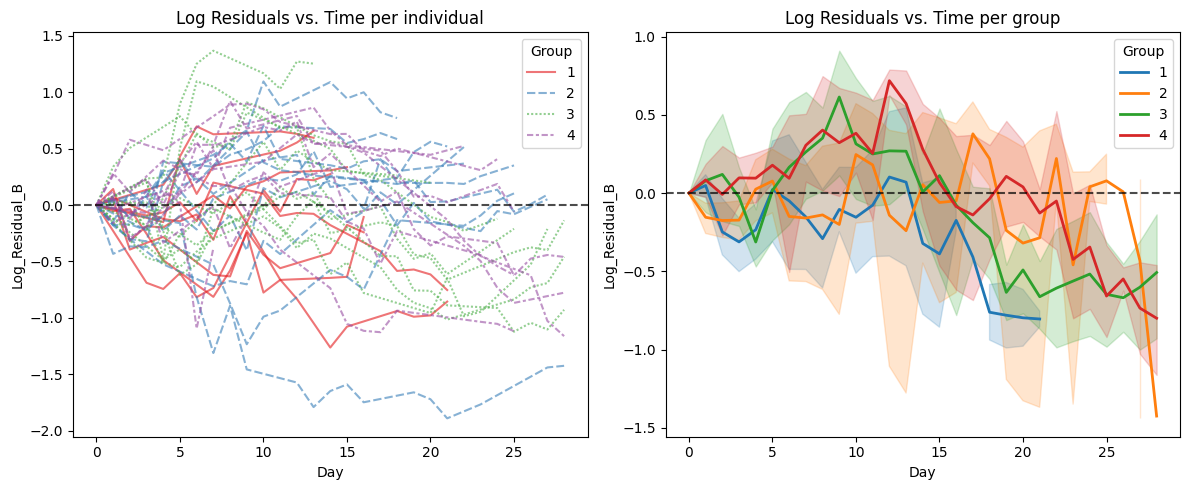

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.lineplot(data=data_pred_b, x="Day", y="Log_Residual_B", hue="Group", style="Group", units="ID", estimator=None, alpha=0.6, palette="Set1", legend="full", ax=ax1)
ax1.set_title("Log Residuals vs. Time per individual")
ax1.axhline(0, color="black", linestyle="--", alpha=0.7)

sns.lineplot(data=data_pred_b, x="Day", y="Log_Residual_B", hue="Group", palette="tab10", linewidth=2, ax=ax2)
ax2.set_title("Log Residuals vs. Time per group")
ax2.axhline(0, color="black", linestyle="--", alpha=0.7)

plt.tight_layout()
fig.savefig(EXPORT_PATH / "fig11.png", dpi=300, bbox_inches="tight")
plt.show()

## Advanced Model

Next, the advanced model will be fitted to the available data in order to begin its validation.

In [12]:
%%time
seed = 23 ; maxiter = 100 ; popsize = 10

results_df_adv = fit_model_advanced(data, seed, maxiter, popsize)
results_df_adv.head()

CPU times: total: 3min 2s
Wall time: 3min 26s


,Group,r_s,r_r,K,mu,al,MSE
0,1,0.337268,0.01,4055.517902,0.05,0.000000,0.28001
1,2,0.337268,0.01,4055.517902,0.05,0.115620,0.28001
2,3,0.337268,0.01,4055.517902,0.05,0.070870,0.28001
3,4,0.337268,0.01,4055.517902,0.05,0.123184,0.28001


Similarly to the Basic Model, the advanced model predictions and its log-residuals will be added to the original dataset for convenience.

In [36]:
def add_predictions_advanced(data: pd.DataFrame, results_df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds 'Pred_Size_A' and 'Log_Residual_A' columns to the original dataset.

    Input:
    ----------
    data: Original dataset (pd.DataFrame)
    results_df: Dataset (pd.DataFrame) storing the parameters obtained after fitting the Advanced Model to the available data

    Output:
    ----------
    df: pd.DataFrame copy of the original dataset with the extra columns 'Pred_Size_A' and 'Log_Residual_A'
    """
    df = data.copy()
    df["Pred_Size_A"] = np.nan

    # Extract fitted parameters
    r_s = results_df["r_s"].iloc[0]
    r_r = results_df["r_r"].iloc[0]
    K = results_df["K"].iloc[0]
    mu = results_df["mu"].iloc[0]
    al_lookup = dict(zip(results_df["Group"], results_df["al"]))

    for mouse_id in df["ID"].unique():
        mouse_mask = df["ID"] == mouse_id
        mouse_df = df.loc[mouse_mask]

        T_obs = mouse_df["Size"].to_numpy()
        T0 = T_obs[0]
        times = mouse_df["Day"].to_numpy()
        grp = mouse_df["Group"].iloc[0]

        D = grp > 0

        sim_df = simulate_tumor_advanced(
            T0=T0,
            r_s=r_s,
            r_r=r_r,
            K=K,
            al=al_lookup[grp],
            mu=mu,
            times=times,
            D=D)

        df.loc[mouse_mask, "Pred_Size_A"] = sim_df["Size"].values

    df["Log_Residual_A"] = np.log(df["Size"]) - np.log(df["Pred_Size_A"])

    return df

data_pred_adv = add_predictions_advanced(data, results_df_adv)
data_pred_adv.head()

,Grp,Group,ID,Day,Size,Baseline,RTV,Pred_Size_A,Log_Residual_A
0,1.CTR,1,101,0,41.8,41.8,1.000000,41.800000,0.000000
1,1.CTR,1,101,3,85.0,41.8,2.033493,96.462539,-0.126503
2,1.CTR,1,101,4,114.0,41.8,2.727273,125.576410,-0.096716
3,1.CTR,1,101,5,162.3,41.8,3.882775,162.567432,-0.001646
4,1.CTR,1,101,6,178.3,41.8,4.265550,209.375317,-0.160661


As done with the basic model, the first step is to plot residuals vs. time to check whether the model captures the underlying system dynamics.

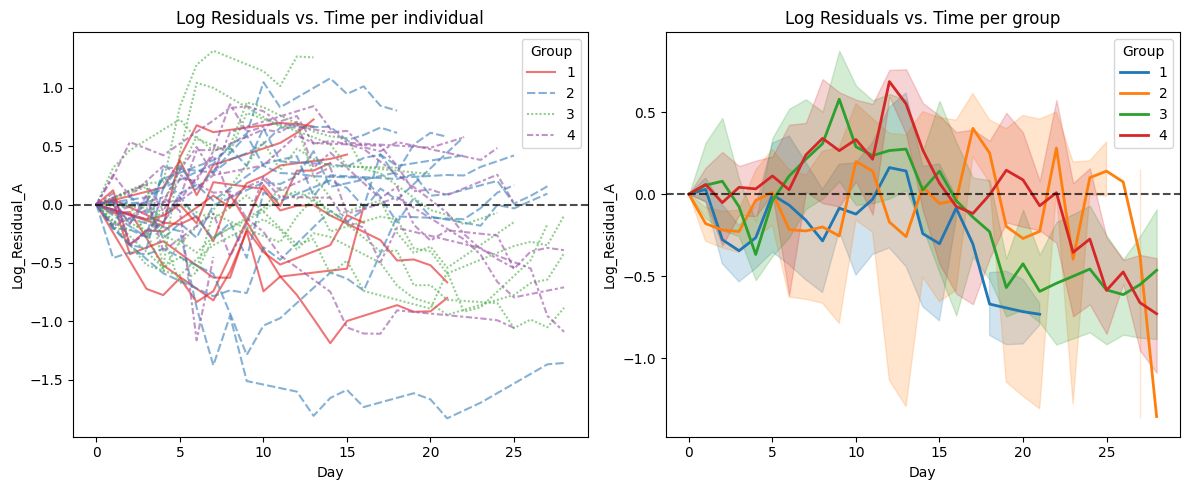

In [40]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.lineplot(data=data_pred_adv, x="Day", y="Log_Residual_A", hue="Group", style="Group", units="ID", estimator=None, alpha=0.6, palette="Set1", legend="full", ax=ax1)
ax1.set_title("Log Residuals vs. Time per individual")
ax1.axhline(0, color="black", linestyle="--", alpha=0.7)

sns.lineplot(data=data_pred_adv, x="Day", y="Log_Residual_A", hue="Group", palette="tab10", linewidth=2, ax=ax2)
ax2.set_title("Log Residuals vs. Time per group")
ax2.axhline(0, color="black", linestyle="--", alpha=0.7)

plt.tight_layout()
fig.savefig(EXPORT_PATH / "fig12.png", dpi=300, bbox_inches="tight")
plt.show()

## Diagnostic

From the previous plots the following can be extracted:

- Both spaghetti plots (which enable to analyze the performance of the model for each individual) clearly exhibit that lines do not oscillate randomly around zero; instead, individual mice stay consistently above or below for extended periods. This indicates high serial autocorrelation (if the previous residual was positive, the next one tends to be positive and viceversa) and highlits mouse-specific growth dynamics not captured by a single set of group parameters.
- Moreover, in the group trend plots, mean *log-residuals* show a strong negative slope toward the end of the experiment across all groups.
- Finally, the shaded CI widen substantially after days 15-20, reflecting higher uncertainty and sparse data points as mice drop out.

These observations motivate the following conclusions:

- The strong drop to negative residuals in later days means that the model is overpredicting tumor sizes. This is probably caused by the fact that mice that presented faster-growing tumors had to be euthanized before the end of the experiment, which means that mice observed after day $\approx 20$ represent a subpopulation of slower-growing tumors. Because the model was fitted using shared growth/carrying capacity parameters influenced by early fast growers, it overpredicts the volume of the surviving slow growers at late stages (clear example of **survivorship bias**).
- Both models exhibit structural misspecification, therefore the adding of resistance dynamics provides marginal improvement in the fitting (resistance growth rate or mutation rate do not capture how treated tumors plateau).
- There clearly is an unmodeled inter-individual variability, which the fitted models do not account for.

These diagnostics clearly indicate that this model is statistically invalid for this dataset, which motivates the creation of a new model that will be described in the following:

## New Model

The new model targets the three structural failures identified in the residual analysis: serial autocorrelation, survivorship bias from euthanasia and parameter unidentifiability.

#### Mouse-Specific Random Effect on Growth Rate:
In the previous models, a single growth rate $r$ was fitted for every mouse in the dataset. This has been proven to be an over-simplification of reality, in which even genetically identical mice exhibit different tumor growth dynamics (due to differences in tumor vascularization, immune microenvironment, etc.). For this reason, the new model will estimate an individual growth rate $r_i$ for each mouse as: $$r_i = \bar{r} + \eta_i, \quad \eta_i \sim \mathcal{N}(0, \sigma_r^2)$$ where: $\bar{r}$ is the average tumor growth rate for all groups and $\sigma_r^2$ is a parameter quantifying between-mouse biological variability (the differences between treatment groups are modeled exclusively through the treatment efficiency parameters $\alpha_g$).

For a new mouse, the random effect is set to its expected value (0) and the model predicts using the population-average growth rate. Once new observations are obtained from the mouse, the predicted trajectory can be customized taking this observations into account.

#### Time-truncation 
Mice with fast-growing tumors had to be euthanized at day $\approx 15$, leaving only mice with slower-growing tumors after that. Fitting across the entire time domain caused the model to overpredict the surviving slow-grower population (resuduals experienced a sharp drop after day 15). For that reason, this model will only be fitted with data where $Day \leq 15$

#### Parsimonious architecture
With the available data it was not statistically possible to identify both $r_r$ and $\mu$ (structural unidentifiability), therefore the new model will only contemplate one type of population.

#### Model Equation
Therefore, the equation of the new model is:
$$T_{i,t+1} = T_{i,t} + (\bar{r} + \eta_i)T_{i,t}(1 - \frac{T_{i,t}}{K}) - \alpha_g D T_{i,t}$$